# This notebook was used for local evaluation purposes

----

# Deep Learning for Video Signal Processing (DLVSP)
## Master in Deep Learning for Audio and Video Signal Processing (MUDLAVSP)
## Universidad Autonoma de Madrid

## **Tutorial: multiple object tracking**

This tutorial will show you **how to define and run a simple multi-object tracker**. This tracker is based on the tracking-by-detection scheme. Hence, the first step is an object detector which is applied to each frame independently and the second step is data association where the detections are linked to the tracks of the previous frame.

This tutorial makes use of the [MOT challenge datasets](https://motchallenge.net/data/). To compare tracking performance of different trackers without the effect of the object detector, the [MOTChallenge](https://motchallenge.net/) often provides precomputed sets of public object detections. Trackers are then evaluated on their capabilities to form tracks with the provided set. However, this tutorial uses detections computed with your own detector (`private detections`).

Author: Juan Carlos San Miguel (juancarlos.sanmiguel@uam.es)


# 1 Setup (only if run this notebook in Colab)

This setup will guide you to **install and configure the software for running the tutorial using cloud** resources via `Google Colaboratory`

Alternatively, this tutorial can be also run using local resources (i.e. lab computers) with Jupyter notebooks and through `Colab` (see for example this [link](https://research.google.com/colaboratory/local-runtimes.html#:~:text=In%20Colaboratory%2C%20click%20the%20%22Connect,connected%20to%20your%20local%20runtime)). For step-by-step details regarding local runtime, please refer to the instructions in the challenge description available in Moodle.


## 1.1 Install Python libraries

The following code will install some required packages and the utilities to compute the performance evaluation metrics `py-motmetrics` (an alternative link is available in case the official one does not work).

This tutorial has been tested in `Google Colaboratory` for the following versions:
* `Python` 3.10.X
* `Pytorch` 2.1.0 with `torchvision` 0.16.0 and `torchaudio` 2.1.0
* Support for `CUDA` libraries 12.1

At your own risk, feel free to employ other versions for the required packages.


In [ ]:
# !pip3 install tqdm lap
# !pip3 install torch==2.9.0+cu126 torchvision==0.24.0+cu126 torchaudio===2.9.0+cu126 --extra-index-url https://download.pytorch.org/whl/cu126 #Pytorch and requirements
# #!pip3 install http://www-vpu.eps.uam.es/~jcs/teaching/DLVSP/py-motmetrics-fix_pandas_deprecating_warnings.zip # #Evaluation metrics for MOT (python < 3.8)
# !pip3 install http://www-vpu.eps.uam.es/~jcs/teaching/DLVSP/py-motmetrics-fix_pandas_deprecating_warnings_python310.zip # #Evaluation metrics for MOT (python >= 3.8)

In [1]:
import torch, torchvision, torchaudio
!python --version
print(torch.__version__)
print(torchvision.__version__)
print(torchaudio.__version__)

Python 3.10.19
2.9.0
0.24.0
2.9.0


## 1.2 Connect to Google Drive
We will connect to your Google Drive account so we can save downloaded data and obtained results.

If you are not using `Google Colaboratory` (e.g. running the notebook in computer labs), you do not need to execute the following code and also, you may need changing the paths indicated by `download_dir` and `working_dir` to suitable locations adapted to your setup.

In [2]:
# # Connet to Google Drive
# from google.colab import drive
# drive.mount('/content/gdrive', force_remount=True)

## 1.3 Download material for the assignment

We will download the material for the assignment in [this zip file](http://www-vpu.eps.uam.es/~jcs/DLVSP/dlvsp_prc4_material.zip) to your Google Drive account.

The `download_dir` path points to the downloads directory in your Google Drive. You need to download this file once.


In [3]:
# import os, subprocess

# # path to download in Google Drive
# download_dir = '/content/gdrive/My Drive/downloads/'

# # file with the material for the assignment (1.3GB)
# urlfile = 'http://www-vpu.eps.uam.es/~jcs/teaching/DLVSP/dlvsp_challenge_material.zip'
# datafile = os.path.basename(urlfile) #with extension

# # Download material if not available in download directory
# datadownload_path = os.path.join(download_dir,datafile)
# if os.path.isfile(datadownload_path) == False:
#   !curl $urlfile --create-dirs -o "$datadownload_path"
#   print('The file \'{}\' has been downloaded to directory \'{}\''.format(datafile,download_dir))
# else:
#   print('The file \'{}\' is already available in the directory \'{}\''.format(datafile,download_dir))

## 1.4 Copy material to local directory

We will copy the downloaded material to a local directory of the Virtual Machine (VM), as the processing/reading is faster than using Drive folders. The `working_dir` path points to a working directory in the Virtual Machine .

Data (dataset and source code files) is copied from the `download_dir` directory to the `working_dir` directory.

In [2]:
# import os, subprocess, zipfile
# from tqdm.autonotebook import tqdm

# # path to working directory (local, will be deleted when VM disconnected)
working_dir = "/Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_material" # '/content/work/' 

# # copy downloaded file to the working directory
# print('Copying file \'{}\' from \'{}\' to \'{}\'...'.format(datafile,download_dir,working_dir))
# if os.path.isfile(os.path.join(working_dir,datafile)) == False:
#   !rsync -ah --progress "$datadownload_path" "$working_dir"
# else:
#   print('already exists!')

# # uncompress/unzip file in the working directory
# print('\nUnzipping file \'{}\' in directory \'{}\'...'.format(datafile, working_dir), end='')
# if os.path.isdir(os.path.join(working_dir,'data')) == False:
#   with zipfile.ZipFile(os.path.join(working_dir,datafile)) as zf:
#     for member in tqdm(zf.infolist(), desc='Extracting '):
#         try:
#           zf.extract(member, working_dir)
#         except zipfile.error as e:
#             pass
# else:
#   print('already unzipped!')

##1.5 Add source code location to system path

We will add the path of the source code provided in the material, so we can import and run the required functionalities for this assignment (tracker, metrics,...).

If everything has been setup correctly, the downloaded source code should be in the directory '/content/work/src/'


In [3]:
import sys,os

# add the path to the system so we can import the tracker
sys.path.append(os.path.join(working_dir,'src/'))

# test that we can successfully import the tracker
from tracker.tracker import Tracker
print('If \'from tracker.tracker import Tracker\' shows no errors, you can import and execute the sample tracker code.\n')
print('Source files of the tracker are available at the directory \'{}\':'.format(working_dir+'src/tracker/'))
!ls $working_dir'/src/tracker/'

print('object_detector.py --> defines the object detector to be employed for tracking (FRCNN_FPN)')
print('tracker.py         --> defines the architecture for developing trackers (i.e. common functions)')
print('data_obj_detect.py --> utility for handing datasets/sequences for object detection')
print('data_track.py      --> utility for handing datasets/sequences for object tracking')
print('utils.py           --> Utilities for evaluation and plotting')

/opt/anaconda3/envs/mot/lib/python3.10/site-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(


If 'from tracker.tracker import Tracker' shows no errors, you can import and execute the sample tracker code.

Source files of the tracker are available at the directory '/Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_materialsrc/tracker/':
__init__.py        data_obj_detect.py object_detector.py tracker.py
__pycache__        data_track.py      reid_extractor.py  utils.py


/opt/anaconda3/envs/mot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


object_detector.py --> defines the object detector to be employed for tracking (FRCNN_FPN)
tracker.py         --> defines the architecture for developing trackers (i.e. common functions)
data_obj_detect.py --> utility for handing datasets/sequences for object detection
data_track.py      --> utility for handing datasets/sequences for object tracking
utils.py           --> Utilities for evaluation and plotting


# 2 Dataset: MOT16

The MOT16 challenge provides 7 train and 7 test video sequences with multiple objects (pedestrians) per frame. It includes many challening scenarios with camera movement, high crowdedness and object occlusions. See the [webpage](https://motchallenge.net/data/MOT16/) for video sequences with ground truth annotation. For the `train` set, ground-truth data and images are provided, so you can train and evaluate your algorithm. For the `test` set, only images are provided and ground-truth data is unknown to researchers. The evaluation is carried out using an evaluation server at the [MOT challenge site](https://motchallenge.net/instructions/). This evaluation scheme prevents cheating by doing training also on the `test` set.


##2.1 Train/test split

For this assignment, we use the `train` set of MOT16 (7 sequences) and selected data from the [MOT challenge](https://motchallenge.net) as our `test` (XX sequences). The following code shows the train and test sets available in the downloaded material:

In [4]:
#list the contents of the 'train' directory
train_dir = os.path.join(working_dir,'data/MOT16/train')
print('Train directory:')
!ls $train_dir

#list the contents of the 'test' directory
test_dir = os.path.join(working_dir,'data/MOT16/test')
print('Test directory:')
!ls $test_dir

Train directory:
MOT16-02 MOT16-04 MOT16-05 MOT16-09 MOT16-10 MOT16-11 MOT16-13
Test directory:
MOT16-95 MOT16-96 MOT16-97 MOT16-98 MOT16-99


## 2.2 Visualization

The following code shows the ground-truth detections for each sequence in the `train` and `test` sets.

The `MOT16Sequences` dataset class provides the possibilty to load single sequences, e.g., `seq_name = 'mot16_02'`, or the entire train/test set, e.g., `seq_name = 'mot16_train'`. The associated code is defined in the file `./src/tracker/data_track.py`

**Here, only the first image of a sequence is shown.**

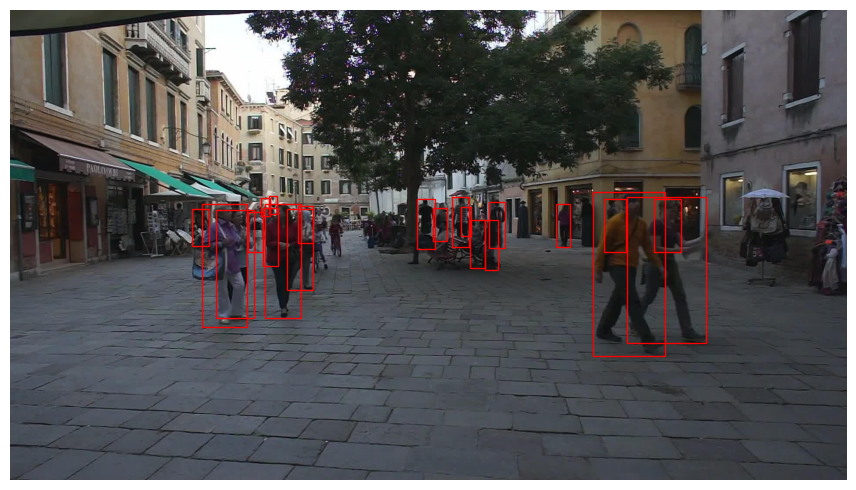

In [ ]:
import matplotlib.pyplot as plt
from tracker.data_track import MOT16Sequences

seq_name = 'MOT16-02' #uncomment to show a single sequence
#seq_name = 'MOT16-train' #uncomment to show one frame for each sequence in the train split
#seq_name = 'MOT16-test' #uncomment to show one frame for each sequence in the test split
data_dir = os.path.join(working_dir,'data/MOT16')
sequences = MOT16Sequences(seq_name, data_dir, load_seg=True)

for seq in sequences:
    for i, frame in enumerate(seq):
        img = frame['img']

        dpi = 96
        fig, ax = plt.subplots(1, dpi=dpi)

        img = img.mul(255).permute(1, 2, 0).byte().numpy()
        width, height, _ = img.shape

        ax.imshow(img, cmap='gray')
        fig.set_size_inches(width / dpi, height / dpi)

        if 'gt' in frame:
            gt = frame['gt']
            for gt_id, box in gt.items():
                rect = plt.Rectangle(
                  (box[0], box[1]), box[2] - box[0],box[3] - box[1],
                  fill=False,
                  edgecolor="red",
                  linewidth=1.0)
                ax.add_patch(rect)

        plt.axis('off')
        plt.show()

        break #we only plot the first image for each sequence

#3 Object detector

We provide you with an object detector pretrained on the MOT challenge training set. This detector can be used and improved to generate the framewise detections necessary for the subsequent tracking and data association step.

The object detector is a [Faster R-CNN](https://arxiv.org/abs/1506.01497) with a Resnet50 feature extractor. We trained the native PyTorch implementation of Faster-RCNN for pedestrian detection. For more information check out the corresponding PyTorch [tutorial](https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html).

The associated code is defined in the file `./src/tracker/object_detector.py`

## 3.1 Model

The trained model is provided in the directory `model_dir`.

In [6]:
# path for the source code of the tracker
model_dir=working_dir+'models/'

print('Model files of the tracker are available at the directory \'{}\':'.format(model_dir))
!ls "$model_dir"

Model files of the tracker are available at the directory '/Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_materialmodels/':
ls: /Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_materialmodels/: No such file or directory


##3.2 Configuration
The configuration of the detector is described as follows:

In [7]:
import torch

#select GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
# if torch.mps.is_available():
#     device = torch.device('mps') # for apple silicon macs
    
#     import os
#     os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
print('Computation device: ', device)

#location of the model file
obj_detect_model_file = os.path.join(working_dir, "models/faster_rcnn_fpn.model")

#threshold for non maximum suppression
obj_detect_nms_thresh = 0.3

#detector has been trained for two classes
num_classes=2 # 1 class (person) + background (see https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html)

# rpn_pre_nms_top_n_train=1000,
# rpn_pre_nms_top_n_test=500,
# rpn_post_nms_top_n_train=1000,
# rpn_post_nms_top_n_test=500,

Computation device:  cpu


##3.3 Creation of the object detector

To create the object detector, we will use the functionality provided in the file `./src/tracker/object_detector.py`.

In [8]:
from tracker.object_detector import FRCNN_FPN

# object detector
obj_detect = FRCNN_FPN(num_classes=num_classes, nms_thresh=obj_detect_nms_thresh)
obj_detect_state_dict = torch.load(obj_detect_model_file,map_location=lambda storage, loc: storage)
obj_detect.load_state_dict(obj_detect_state_dict)

trainable_params = sum(p.numel() for p in obj_detect.parameters() if p.requires_grad)
print(f"The object detector has {trainable_params} trainable parameters.")

# prints the architecture and sets the model to evaluation mode.
obj_detect.eval()

# loads detector to CPU or GPU (if available)
obj_detect.to(device)

/opt/anaconda3/envs/mot/lib/python3.10/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' and 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/opt/anaconda3/envs/mot/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


The object detector has 41076761 trainable parameters.


FRCNN_FPN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu)

##3.4 Evaluate the object detector

In addition, the trained object detector can be evaluated on the `MOT16` dataset.
To load the  MOT16 data (images and ground-truth bounding boxes), we will use functionality provide by MOT16 dev kit (`./src/tracker/data_obj_detect.py`) and Pytorch (`Dataloader`).

To perform such evaluation, we will use functionalities provided in the file `./src/tracker/utils.py`. If you run the following code, you will get an evaluation of the object detector over the `train` set (estimated execution time is 15-20 minutes).

In [ ]:
from torch.utils.data import DataLoader
from tracker.data_obj_detect import MOT16ObjDetect
from tracker.utils import (evaluate_obj_detect, obj_detect_transforms)

from tqdm.auto import tqdm

#load train set for the MOT16 data (images and ground-truth bounding boxes)
dataset_test = MOT16ObjDetect(os.path.join(working_dir, 'data/MOT16/train'), obj_detect_transforms(train=False))

def collate_fn(batch):
    return tuple(zip(*batch))

num_workers = 2 if torch.cuda.is_available() else 0
data_loader_test = DataLoader(dataset_test, batch_size=4, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)

#evaluation
evaluate_obj_detect(obj_detect, data_loader_test)

#4 Multi-object tracking

We provide a simple baseline tracker which predicts object detections for each frame and generates tracks by assigning current detections to previous detections via Intersection over Union.

**Your task is to work using this baseline, trying to improve the performance (`MOTA` metric).**

## 4.1 Configuration
First, we must set the seed to allow repeable results

In [9]:
import torch
import numpy as np

seed = 12345 #seed to allow repeatable results
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True

Then, we need to define the object detector, the sequences to be analyzed and the output directory.

In [10]:
import torch
import sys,os
from tracker.data_track import MOT16Sequences
from tracker.reid_extractor import ReIDExtractor

# working directory
# working_dir = '/content/work/' # assumed that steps 1.4 & 1.5 have done, so source code is in "working_dir"
# sys.path.append(os.path.join(working_dir,'src/'))

from tracker.object_detector import FRCNN_FPN

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# object detector
num_classes=2 # 1 class (person) + background (see https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html)
obj_detect_model_file = os.path.join(working_dir, "models/faster_rcnn_fpn.model") #location of the model file
obj_detect_nms_thresh = 0.3 #threshold for non maximum suppression

obj_detect = FRCNN_FPN(
    num_classes=num_classes, 
    nms_thresh=obj_detect_nms_thresh, 
    # rpn_pre_nms_top_n_train=rpn_pre_nms_top_n_train,
    # rpn_pre_nms_top_n_test=rpn_pre_nms_top_n_test,
    # rpn_post_nms_top_n_train=rpn_post_nms_top_n_train,
    # rpn_post_nms_top_n_test=rpn_post_nms_top_n_test,
    # rpn_pre_nms_top_n={
    #     "training": rpn_pre_nms_top_n_train,
    #     "testing": rpn_pre_nms_top_n_test,
    # },
    # rpn_post_nms_top_n={
    #     "training": rpn_post_nms_top_n_train,
    #     "testing": rpn_post_nms_top_n_test,
    # },
)
obj_detect_state_dict = torch.load(obj_detect_model_file,map_location=lambda storage, loc: storage)
obj_detect.load_state_dict(obj_detect_state_dict)
obj_detect.eval()     # set to evaluation mode
obj_detect.to(device) # load detector to GPU or CPU

reid_extractor = ReIDExtractor(device)

# dataset
seq_name = 'MOT16-train' # uncomment to run the tracker over the train set
#seq_name = 'MOT16-test' # uncomment to run the tracker over the test set
#seq_name = 'MOT16-02'   # uncomment to run the tracker over the sequence 'MOT16-02'
data_dir = os.path.join(working_dir, 'data/MOT16')
sequences = MOT16Sequences(seq_name, data_dir)
print('Loaded {:d} sequences for {:s}'.format(len(sequences),seq_name))

#output directory
output_dir = os.path.join(working_dir, 'output')

Successfully loaded imagenet pretrained weights from "/Users/marcelhofmann/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth"
Loaded 7 sequences for MOT16-train


## 4.2 Extend the baseline tracker

The class `Tracker` in file `./src/tracker/tracker.py` contains the skeleton of the baseline tracker. You modifications and improvements should be based on this class.

As a suggestion, we provide a code example to extend the functionality of the baseline tracker by overriding the `data_association` function (which is empty in the baseline tracker). This extensions generates tracks by assigning current detections to previous detections via `Intersection over Union` in a greedy way.

In [11]:
import numpy as np
import motmetrics as mm
mm.lap.default_solver = 'lap'
from tracker.tracker import Tracker

# extended class 'Tracker' based on IoU criterion
class TrackerIoUAssignment(Tracker):

    def data_association(self, boxes, scores):
        if self.tracks:
            track_ids = [t.id for t in self.tracks]
            track_boxes = np.stack([t.box.numpy() for t in self.tracks], axis=0)

            # compute distance based on IoU (distance=1-IoU)
            distance = mm.distances.iou_matrix(track_boxes, boxes.numpy(), max_iou=0.5)

            # update existing tracks
            remove_track_ids = []
            for t, dist in zip(self.tracks, distance):
                if np.isnan(dist).all():
                    remove_track_ids.append(t.id)
                else:
                    match_id = np.nanargmin(dist)
                    t.box = boxes[match_id]
            self.tracks = [t for t in self.tracks
                           if t.id not in remove_track_ids]

            # add new tracks
            new_boxes = []
            new_scores = []
            for i, dist in enumerate(np.transpose(distance)):
                if np.isnan(dist).all():
                    new_boxes.append(boxes[i])
                    new_scores.append(scores[i])
            self.add(new_boxes, new_scores)

        else:
            self.add(boxes, scores)

# create a new tracker using the 'TrackerIoUAssignment' class
tracker = Tracker(obj_detect, reid_extractor)#TrackerIoUAssignment(obj_detect)
print('Tracker created!')

Tracker created!


## 4.3 Run tracker
The following code runs the tracker created previously for the `train` sequences. It also prints some statistics for each sequence.

The estimated running time for the entire `train` set (7 sequences) is ~20 minutes, and for the entire `test` set (5 sequences) is ~5 minutes.

In [12]:
import time
from tqdm.autonotebook import tqdm
from torch.utils.data import DataLoader
from tracker.utils import get_mot_accum

time_total = 0
mot_accums = []
results_seq = {}

for seq in sequences:
    print(f"Tracking: {seq}")
    now = time.time()

    # restart tracker state for each sequence
    tracker.reset()

    #load data
    data_loader = DataLoader(seq, batch_size=1, shuffle=False) # batch size shouldnt be changed, no shuffling for tracking because logical order is needed

    #run tracker
    with torch.inference_mode(): # torch.no_grad()
        for frame in tqdm(data_loader):
            tracker.step(frame)

    #keep results
    results = tracker.get_results()
    results_seq[str(seq)] = results

    #perform evaluation
    if seq.no_gt:
        print(f"No GT evaluation data available.")
    else:
        mot_accums.append(get_mot_accum(results, seq)) #compute and store eval metrics

    time_total += time.time() - now

    print(f"Tracks found: {len(results)}")
    print(f"Runtime for {seq}: {time.time() - now:.1f} s.")

    #save results to output directory
    seq.write_results(results, os.path.join(output_dir))

Tracking: MOT16-13


100%|██████████| 750/750 [13:18<00:00,  1.06s/it]


Tracks found: 588
Runtime for MOT16-13: 806.1 s.
Writing predictions to: /Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_material/output/MOT16-13.txt
Tracking: MOT16-09


100%|██████████| 525/525 [08:05<00:00,  1.08it/s]


Tracks found: 60
Runtime for MOT16-09: 489.7 s.
Writing predictions to: /Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_material/output/MOT16-09.txt
Tracking: MOT16-10


...

Tracks found: 240
Runtime for MOT16-05: 625.3 s.
Writing predictions to: /Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_material/output/MOT16-05.txt
Tracking: MOT16-02


100%|██████████| 600/600 [10:52<00:00,  1.09s/it]


Tracks found: 225
Runtime for MOT16-02: 658.9 s.
Writing predictions to: /Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_material/output/MOT16-02.txt
Tracking: MOT16-04


100%|██████████| 1050/1050 [1:23:46<00:00,  4.79s/it]   


Tracks found: 170
Runtime for MOT16-04: 5041.5 s.
Writing predictions to: /Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_material/output/MOT16-04.txt


## 4.4 Evaluate tracking results

The following code computes the performance evaluation metrics for the generated tracking results. You can check the definitions of the evaluation metrics at this [paper](https://arxiv.org/abs/1603.00831).

**Be aware that you can only compute the evaluation metrics for the `train` set, as it has ground-truth data available. The `test` set does not contain ground-truth data (only frames and detections), so running this code cell will not generate any output. The performance evaluation for the `test` set will be done by the course organizers.

The estimated running time for the entire `train` set (7 sequences) is ~6-7 minutes.

In [13]:
from tracker.utils import evaluate_mot_accums
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Backward-compatibility monkey patches for pandas >= 2.0
import pandas as pd
if not hasattr(pd.DataFrame, "append"):
    pd.DataFrame.append = lambda self, other, **kwargs: pd.concat([self, other], **kwargs)

if not hasattr(pd.Series, "iteritems"):
    pd.Series.iteritems = pd.Series.items

# Evaluation of performance
print(f"Runtime for all sequences: {time_total:.1f} s.")
if mot_accums:
    evaluate_mot_accums(mot_accums,
                        [str(s) for s in sequences if not s.no_gt],
                        generate_overall=True)

Runtime for all sequences: 9200.7 s.
          IDF1   IDP   IDR  Rcll  Prcn  GT  MT  PT ML    FP    FN  IDs   FM  MOTA  MOTP
MOT16-13 62.7% 57.1% 69.5% 87.8% 72.3% 110  86  20  4  3923  1415  346  111 51.2% 0.150
MOT16-09 51.0% 60.5% 44.1% 70.3% 96.6%  26  14  12  0   130  1579   48   49 67.0% 0.100
MOT16-10 45.2% 43.8% 46.7% 82.8% 77.7%  57  39  17  1  3049  2209  383  192 56.1% 0.160
MOT16-11 63.5% 67.1% 60.2% 82.3% 91.8%  75  49  20  6   697  1673   75   52 74.1% 0.097
MOT16-05 57.3% 60.9% 54.1% 74.3% 83.6% 133  67  55 11  1008  1781  131  107 57.8% 0.162
MOT16-02 43.4% 58.0% 34.7% 55.5% 92.8%  62  14  36 12   797  8265  143  145 50.5% 0.107
MOT16-04 67.6% 77.6% 59.8% 75.1% 97.4%  83  40  30 13   955 11848  109  149 72.8% 0.103
OVERALL  58.9% 64.6% 54.1% 74.4% 88.8% 546 309 190 47 10559 28770 1235  805 63.9% 0.119


As a reference, the previous code snippet achieves the following tracking results on the full `MOT16-train` sequences:

          SEQUENCE IDF1   IDP   IDR   Rcll  Prcn  GT  MT  PT  ML   FP    FN   IDs  FM  MOTA  MOTP
          MOT16-10 35.3% 40.6% 31.3% 42.0% 54.5%  57  13  23  21  4503  7448  69  120  6.4% 0.138
          MOT16-13 46.5% 64.2% 36.5% 45.1% 79.2% 110  28  34  48  1375  6393  82  124 32.6% 0.134
          MOT16-05 47.7% 53.9% 42.8% 57.8% 72.7% 133  39  64  30  1502  2917  87  103 34.9% 0.144
          MOT16-09 43.0% 48.8% 38.4% 51.9% 66.1%  26   7  14   5  1420  2559  39   66 24.5% 0.107
          MOT16-02 32.2% 49.8% 23.8% 30.8% 64.4%  62   5  22  35  3170 12858  52   93 13.5% 0.086
          MOT16-04 54.7% 56.2% 53.3% 64.1% 67.6%  83  27  37  19 14601 17064  81  172 33.2% 0.109
          MOT16-11 49.0% 54.1% 44.8% 55.8% 67.5%  75  15  32  28  2542  4166  20   39 28.7% 0.080
          OVERALL  47.2% 53.7% 42.1% 52.4% 66.9% 546 134 226 186 29113 53405 430  717 26.1% 0.111

For your final submission you should focus on improving `MOTA` for the `train` set provided as material of this assignment.

## 4.5 Visualize tracking results

The following code shows some sample results for a particular sequence.

Please note that the results for the sequence must be computed by executing the code in cell 4.3 "Run Tracker". In the following example, for visualizing the sequence `seq_name='MOT16-10'`, the cell 4.3 must be executed with the parameter `seq_name = 'MOT16-train'` or `seq_name = 'MOT16-10'` in cell 4.1

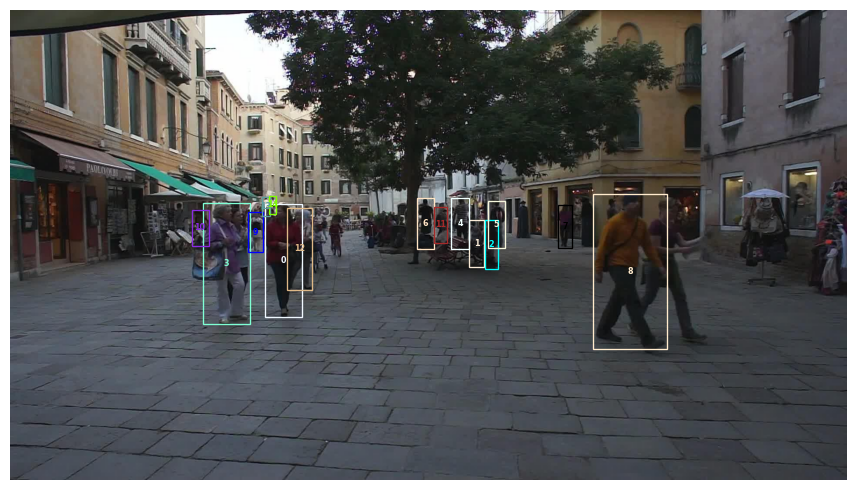

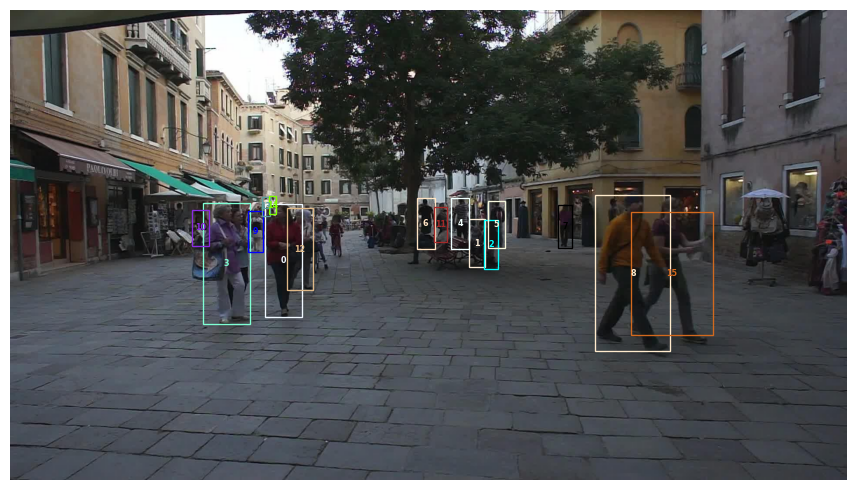

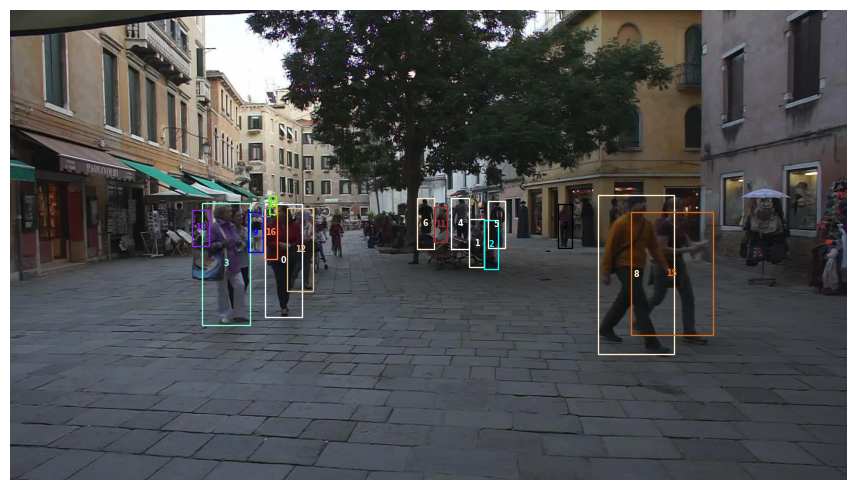

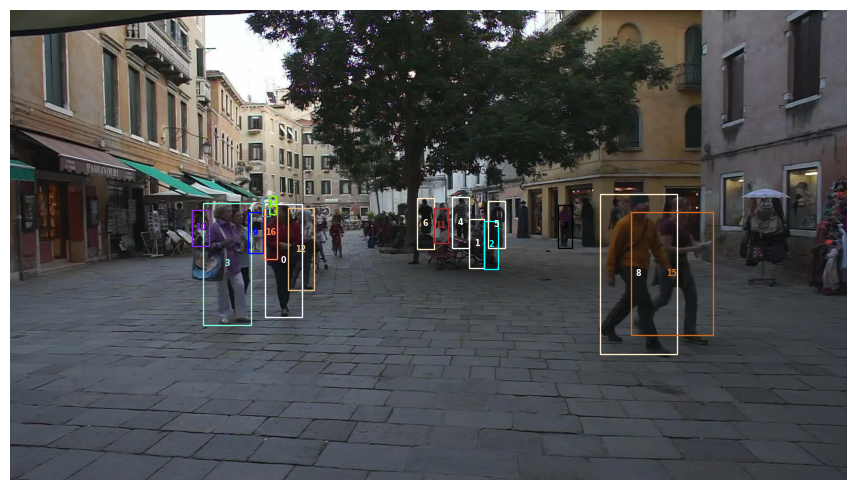

In [14]:
import matplotlib.pyplot as plt
from tracker.utils import plot_sequence

seq_name='MOT16-02' #sequence results corresponding to seq_name = 'MOT16-train'
plot_sequence(results_seq[seq_name],
              [s for s in sequences if str(s) == seq_name][0],
              first_n_frames=3)

# 5 Challenge results
This section provides some utilities for submitting the results of your tracker and participate in the challenge.

Before running the code of this section, you **must need to compute** the following files:
* **Results for the `train`set** (`MOT16-XY.txt` files, 7 in total): these files can be obtained by running the code for section 4.3, with variable `seq_name = 'MOT16-train'` in section 4.1
* **Results for the `test`set** (`MOT16-XY.txt` files, 5 in total): these files can be obtained by running the code for section 4.3, with variable `seq_name = 'MOT16-test'` in section 4.1

## 5.1 Create unified tracking results for the `train` and `test` sets
To handle multiple files for tracking results, this challenge considers joining all the files into a single CSV file with all tracking results. Please run the following code to get the unified files.

**Be sure that you have computed all the required files before executing this code!**

In [15]:
import pandas as pd

sets=['train'] #test
files_sets=[['MOT16-02','MOT16-05','MOT16-04','MOT16-09','MOT16-10', 'MOT16-11','MOT16-13'], #train files
           ['MOT16-95','MOT16-96','MOT16-97','MOT16-98','MOT16-99']] #test files

for files_set, set in zip(files_sets,sets):
  pd_files=[]
  for file in files_set:
    pd_file=pd.read_csv(os.path.join(output_dir,file+'.txt'), header = None)
    pd_file.insert(0, 'seq', file)
    pd_files.append(pd_file)

  set_preds = pd.concat(pd_files, ignore_index=True)
  set_preds.insert(0, 'id', '')
  set_preds['id'] = set_preds.iloc[:, 1:4].astype(str).apply('_'.join, axis=1)
  set_preds = set_preds.drop(set_preds.columns[8:11], axis=1)
  set_preds.to_csv(os.path.join(output_dir,'MOT16-'+set+'.csv'), index=False)
  print('Saved unified file to '+os.path.join(output_dir,'MOT16-'+set+'.csv'))

Saved unified file to /Users/marcelhofmann/Deep_Learning_UAM/Deep_Learning_for_Video_Signal_Processing/MOT_Challenge/dlvsp_challenge_material/output/MOT16-train.csv


## 5.2 Copy results to Google Drive
The `seq.write_results(results, os.path.join(output_dir))` statement saves predicted tracks into files. After executing this cell the `output` directory in your Google Drive should contain multiple `MOT16-XY.txt` files.

Here we will copy these results in the `download_dir` directory of your Google Drive account.

In [ ]:
# #copy output files to download directory in personal Google Drive
# !cp -r $output_dir "$download_dir"

# #show output files
# print('Output tracking results copied to location '+download_dir+' :')
# path = os.path.join(download_dir,"output")
# !ls "$path"